# Modelo Random forest para serie de tiempo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pd.set_option('display.max_rows', 1000)

In [ ]:
df_ventas=pd.read_csv("/content/drive/MyDrive/You tube canal /PANDAS PARA SERIES DE TIEMPO/Random forest retail/train.csv")

In [ ]:
df_ventas.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [ ]:
df_ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [ ]:
df_ventas["date"]=pd.to_datetime(df_ventas["date"])

In [ ]:
df_ventas["store"].unique(),df_ventas["item"].unique()

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
 array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
        35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]))

¿Cómo construir un modelo de series de tiempo para pronosticar las ventas a 1 mes de horizonte (h=31) de la tienda 1?

In [ ]:
df_store1=df_ventas[df_ventas["store"]==1].copy().reset_index(drop=True)

In [ ]:
df_store1.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [ ]:
df_store1.shape

(91300, 4)

In [ ]:
df_store1["item"].nunique()

50

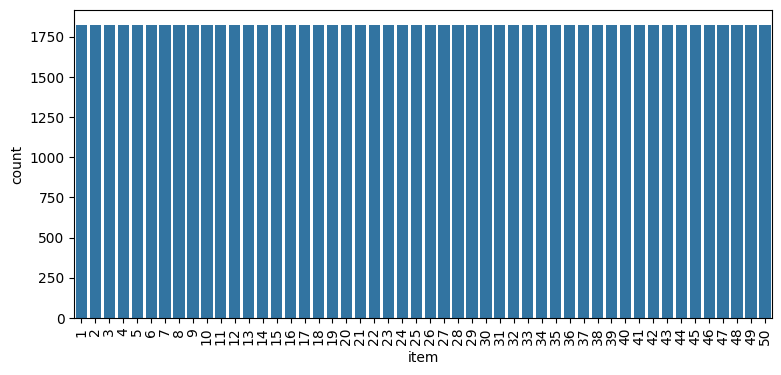

In [ ]:
plt.figure(figsize=(9,4))
sns.countplot(data=df_store1,x="item")
plt.xticks(rotation=90)
plt.show()

In [ ]:
dt_min=df_store1["date"].min()
dt_max=df_store1["date"].max()
print("fecha_minima:",dt_min,"fecha_maxima:",dt_max)
print("total de dias: ",dt_max-dt_min)

fecha_minima: 2013-01-01 00:00:00 fecha_maxima: 2017-12-31 00:00:00
total de dias:  1825 days 00:00:00


In [ ]:
df_store1["item"].value_counts().unique()

array([1826])

In [ ]:
df_store1[(df_store1["date"].dt.year==2016) &(df_store1["date"].dt.month==2)]["date"].unique()

<DatetimeArray>
['2016-02-01 00:00:00', '2016-02-02 00:00:00', '2016-02-03 00:00:00',
 '2016-02-04 00:00:00', '2016-02-05 00:00:00', '2016-02-06 00:00:00',
 '2016-02-07 00:00:00', '2016-02-08 00:00:00', '2016-02-09 00:00:00',
 '2016-02-10 00:00:00', '2016-02-11 00:00:00', '2016-02-12 00:00:00',
 '2016-02-13 00:00:00', '2016-02-14 00:00:00', '2016-02-15 00:00:00',
 '2016-02-16 00:00:00', '2016-02-17 00:00:00', '2016-02-18 00:00:00',
 '2016-02-19 00:00:00', '2016-02-20 00:00:00', '2016-02-21 00:00:00',
 '2016-02-22 00:00:00', '2016-02-23 00:00:00', '2016-02-24 00:00:00',
 '2016-02-25 00:00:00', '2016-02-26 00:00:00', '2016-02-27 00:00:00',
 '2016-02-28 00:00:00', '2016-02-29 00:00:00']
Length: 29, dtype: datetime64[ns]

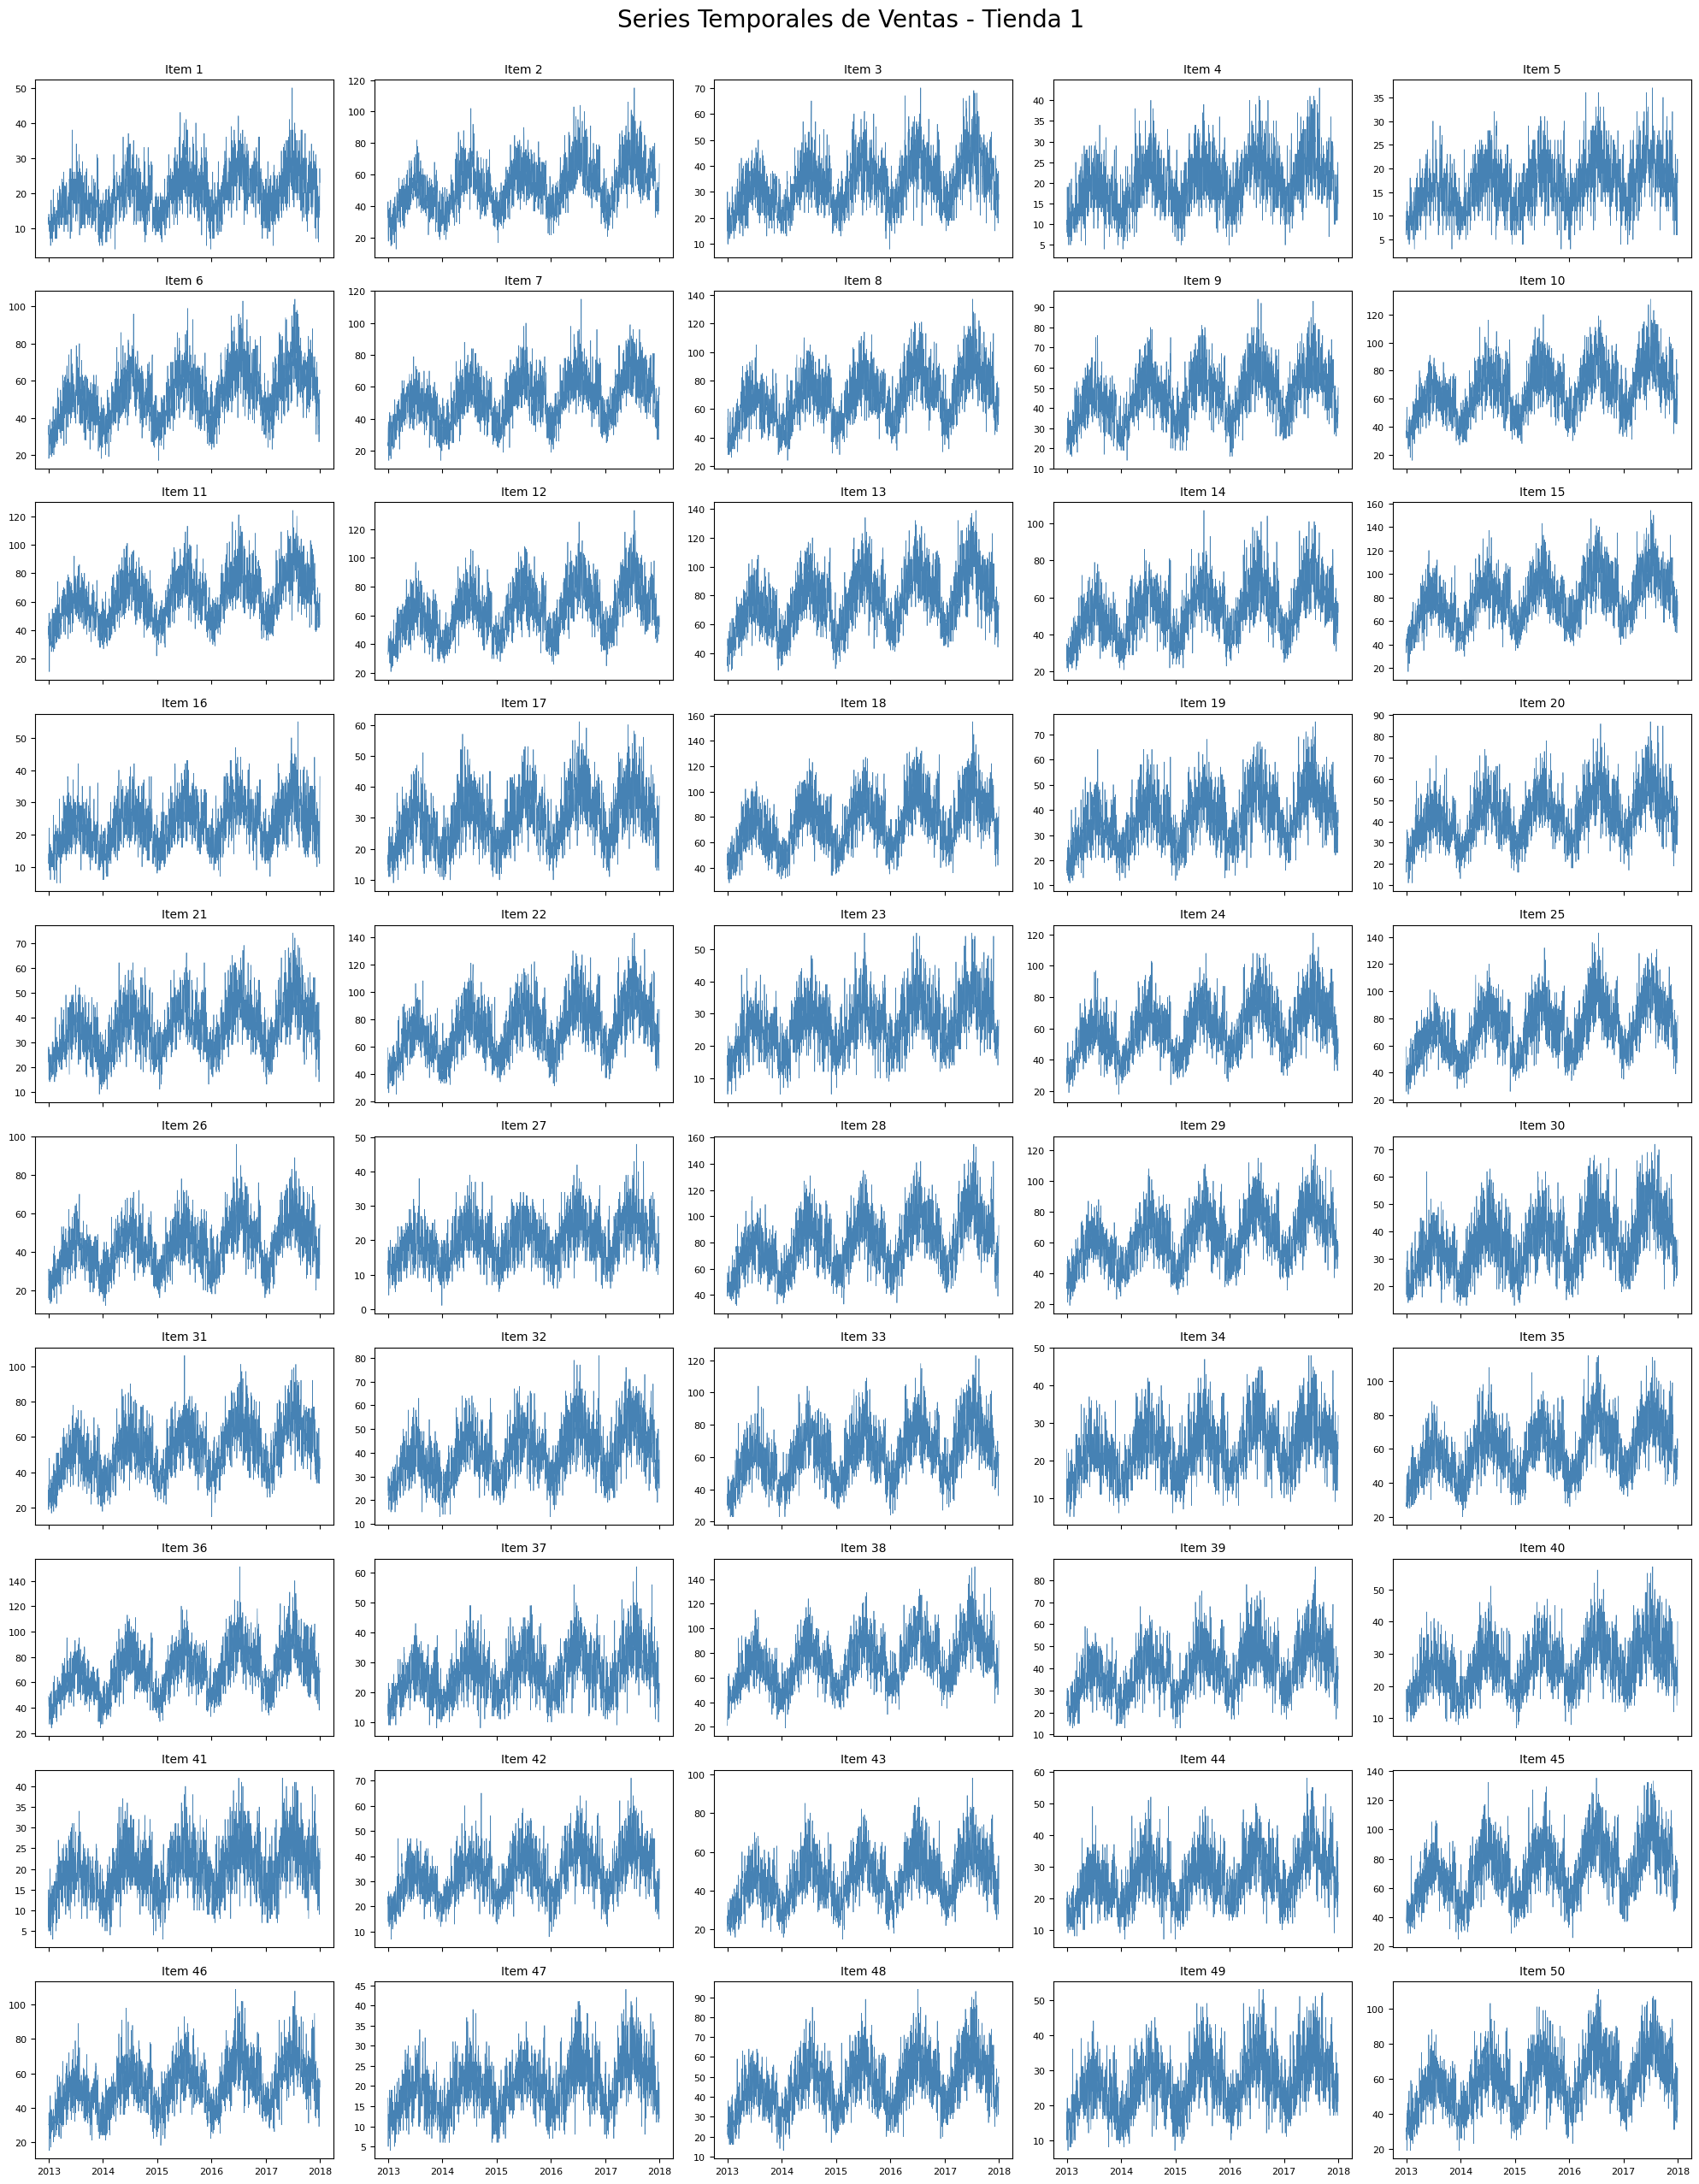

In [ ]:
fig, axes = plt.subplots(nrows=10, ncols=5, figsize=(20, 25), sharex=True)
axes = axes.flatten() # Aplanamos la matriz para iterar fácilmente

# 3. Obtenemos la lista de items únicos
items = sorted(df_store1['item'].unique())

for i, item_id in enumerate(items):
    # Filtrar data del producto específico
    data_item = df_store1[df_store1['item'] == item_id]

    # Graficar en el subgráfico correspondiente
    axes[i].plot(data_item['date'], data_item['sales'], color='steelblue', lw=0.5)
    axes[i].set_title(f'Item {item_id}', fontsize=10)
    axes[i].tick_params(axis='both', which='major', labelsize=8)

    # Opcional: Añadir media móvil para ver tendencia
    # axes[i].plot(data_item['date'], data_item['sales'].rolling(30).mean(), color='orange', lw=1)

# Ajustar diseño para que no se traslapen
plt.tight_layout()
plt.suptitle(f'Series Temporales de Ventas - Tienda {1}', fontsize=20, y=1.02)

# Guardar la imagen para que puedas verla con calma
plt.savefig('ventas_tienda_1_productos.png', dpi=150, bbox_inches='tight')
plt.show()

Total de dias

### Creacion de variables

In [ ]:
df_store1_v2 = df_store1.copy()

Variables calendario:

In [ ]:
df_store1_v2['day'] = df_store1_v2['date'].dt.day
df_store1_v2['dayofweek'] = df_store1_v2['date'].dt.dayofweek
df_store1_v2['month'] = df_store1_v2['date'].dt.month
df_store1_v2['year'] = df_store1_v2['date'].dt.year
df_store1_v2['dayofyear'] = df_store1_v2['date'].dt.dayofyear


In [ ]:
(df_store1_v2['day'].unique(),df_store1_v2['dayofweek'].unique(),df_store1_v2['month'].unique(),
df_store1_v2['year'].unique(),df_store1_v2['dayofyear'].unique())

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31],
       dtype=int32),
 array([1, 2, 3, 4, 5, 6, 0], dtype=int32),
 array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int32),
 array([2013, 2014, 2015, 2016, 2017], dtype=int32),
 array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
         27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
         40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
         53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
         66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
         79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
         92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
        105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
        118, 

In [ ]:
df_store1_v2.head()

,date,store,item,sales,day,dayofweek,month,year,dayofyear
0,2013-01-01,1,1,13,1,1,1,2013,1
1,2013-01-02,1,1,11,2,2,1,2013,2
2,2013-01-03,1,1,14,3,3,1,2013,3
3,2013-01-04,1,1,13,4,4,1,2013,4
4,2013-01-05,1,1,10,5,5,1,2013,5


### variables Lags (retrasos)

In [ ]:
df_store1_v2["lag_1"]=df_store1_v2.groupby(['store', 'item'])['sales'].shift(1)

In [ ]:
df_store1_v2[(df_store1_v2["year"]==2013) & (df_store1_v2["dayofyear"]==1)]

,date,store,item,sales,day,dayofweek,month,year,dayofyear,lag_1
0,2013-01-01,1,1,13,1,1,1,2013,1,NaN
1826,2013-01-01,1,2,33,1,1,1,2013,1,NaN
3652,2013-01-01,1,3,15,1,1,1,2013,1,NaN
5478,2013-01-01,1,4,10,1,1,1,2013,1,NaN
7304,2013-01-01,1,5,11,1,1,1,2013,1,NaN
9130,2013-01-01,1,6,31,1,1,1,2013,1,NaN
10956,2013-01-01,1,7,25,1,1,1,2013,1,NaN
12782,2013-01-01,1,8,33,1,1,1,2013,1,NaN
14608,2013-01-01,1,9,18,1,1,1,2013,1,NaN
16434,2013-01-01,1,10,37,1,1,1,2013,1,NaN


In [ ]:
df_store1_v2["lag_7"]=df_store1_v2.groupby(['store', 'item'])['sales'].shift(7)

In [ ]:
df_store1_v2["lag_30"]=df_store1_v2.groupby(['store', 'item'])['sales'].shift(30)

In [ ]:
df_store1_v2.head(10)

,date,store,item,sales,day,dayofweek,month,year,dayofyear,lag_1,lag_7,lag_30
0,2013-01-01,1,1,13,1,1,1,2013,1,NaN,NaN,NaN
1,2013-01-02,1,1,11,2,2,1,2013,2,13.0,NaN,NaN
2,2013-01-03,1,1,14,3,3,1,2013,3,11.0,NaN,NaN
3,2013-01-04,1,1,13,4,4,1,2013,4,14.0,NaN,NaN
4,2013-01-05,1,1,10,5,5,1,2013,5,13.0,NaN,NaN
5,2013-01-06,1,1,12,6,6,1,2013,6,10.0,NaN,NaN
6,2013-01-07,1,1,10,7,0,1,2013,7,12.0,NaN,NaN
7,2013-01-08,1,1,9,8,1,1,2013,8,10.0,13.0,NaN
8,2013-01-09,1,1,12,9,2,1,2013,9,9.0,11.0,NaN
9,2013-01-10,1,1,9,10,3,1,2013,10,12.0,14.0,NaN


## Variables: Medias moviles

 | Día | Venta |  SMA (3)| Lag SMA (3) |
|-----|-------|-----|-----|
|  1  |  10   |  Na | Na  |
|  2  |  12   |  Na | Na  |
|  3  |  14   |  12 | Na  |
|  4  |  13   |  13 | 12  |
|  5  |  15   |  14 | 13  |
|  6  |  y    |   Na  | 14  |

Día 3 → (10 + 12 + 14) / 3 = 12.0

Día 4 → (12 + 14 + 13) / 3 = 13.0

Día 5 → (14 + 13 + 15) / 3 = 14.0

In [ ]:
df_store1_v2[f'rolling_mean_{7}'] = df_store1_v2.groupby(['store', 'item'])['sales'].transform(
            lambda x: x.shift(1).rolling(window=7).mean()
        )

In [ ]:
df_store1_v2[(df_store1_v2["year"]==2013) & (df_store1_v2["dayofyear"].isin(range(0,9)))].head(8)

,date,store,item,sales,day,dayofweek,month,year,dayofyear,lag_1,lag_7,lag_30,rolling_mean_7
0,2013-01-01,1,1,13,1,1,1,2013,1,NaN,NaN,NaN,NaN
1,2013-01-02,1,1,11,2,2,1,2013,2,13.0,NaN,NaN,NaN
2,2013-01-03,1,1,14,3,3,1,2013,3,11.0,NaN,NaN,NaN
3,2013-01-04,1,1,13,4,4,1,2013,4,14.0,NaN,NaN,NaN
4,2013-01-05,1,1,10,5,5,1,2013,5,13.0,NaN,NaN,NaN
5,2013-01-06,1,1,12,6,6,1,2013,6,10.0,NaN,NaN,NaN
6,2013-01-07,1,1,10,7,0,1,2013,7,12.0,NaN,NaN,NaN
7,2013-01-08,1,1,9,8,1,1,2013,8,10.0,13.0,NaN,11.857143


¿Por que usar transform?
* Devuelve un vector del mismo tamaño que el grupo original

* Mantiene el mismo índice

* Permite asignar directamente el resultado como nueva columna

In [ ]:
df_store1_v2[f'rolling_mean_{30}'] = df_store1_v2.groupby(['store', 'item'])['sales'].transform(
            lambda x: x.shift(1).rolling(window=30).mean()
        )

#### Funcion para creacion de variables

In [ ]:
def create_features(df):
    # Variables de Calendario
    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['dayofyear'] = df['date'].dt.dayofyear

    # Lags (Retrasos)
    for l in [1, 2, 3, 7, 14, 30]:
        df[f'lag_{l}'] = df.groupby(["store",'item'])['sales'].shift(l)

    # Medias Móviles (Rolling Windows)
    for w in [7, 30]:
        df[f'rolling_mean_{w}'] = df.groupby(["store",'item'])['sales'].transform(
            lambda x: x.shift(1).rolling(window=w).mean()
        )

    return df.dropna().reset_index(drop=True)

In [ ]:
df_proc=create_features(df_store1)

In [ ]:
df_proc.head()

,date,store,item,sales,day,dayofweek,month,year,dayofyear,lag_1,lag_2,lag_3,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_30
0,2013-01-31,1,1,13,31,3,1,2013,31,9.0,6.0,11.0,8.0,16.0,13.0,10.285714,10.500000
1,2013-02-01,1,1,11,1,4,2,2013,32,13.0,9.0,6.0,14.0,7.0,11.0,11.000000,10.500000
2,2013-02-02,1,1,21,2,5,2,2013,33,11.0,13.0,9.0,12.0,18.0,14.0,10.571429,10.500000
3,2013-02-03,1,1,15,3,6,2,2013,34,21.0,11.0,13.0,12.0,15.0,13.0,11.857143,10.733333
4,2013-02-04,1,1,14,4,0,2,2013,35,15.0,21.0,11.0,11.0,8.0,10.0,12.285714,10.800000


### Validación Cruzada

#### Backtesting de Reentrenamiento de origen fijado

PASOS PARA PREDICCION SETIEMBRE, OCTUBRE Y NOVIEMBRE DEL 2027

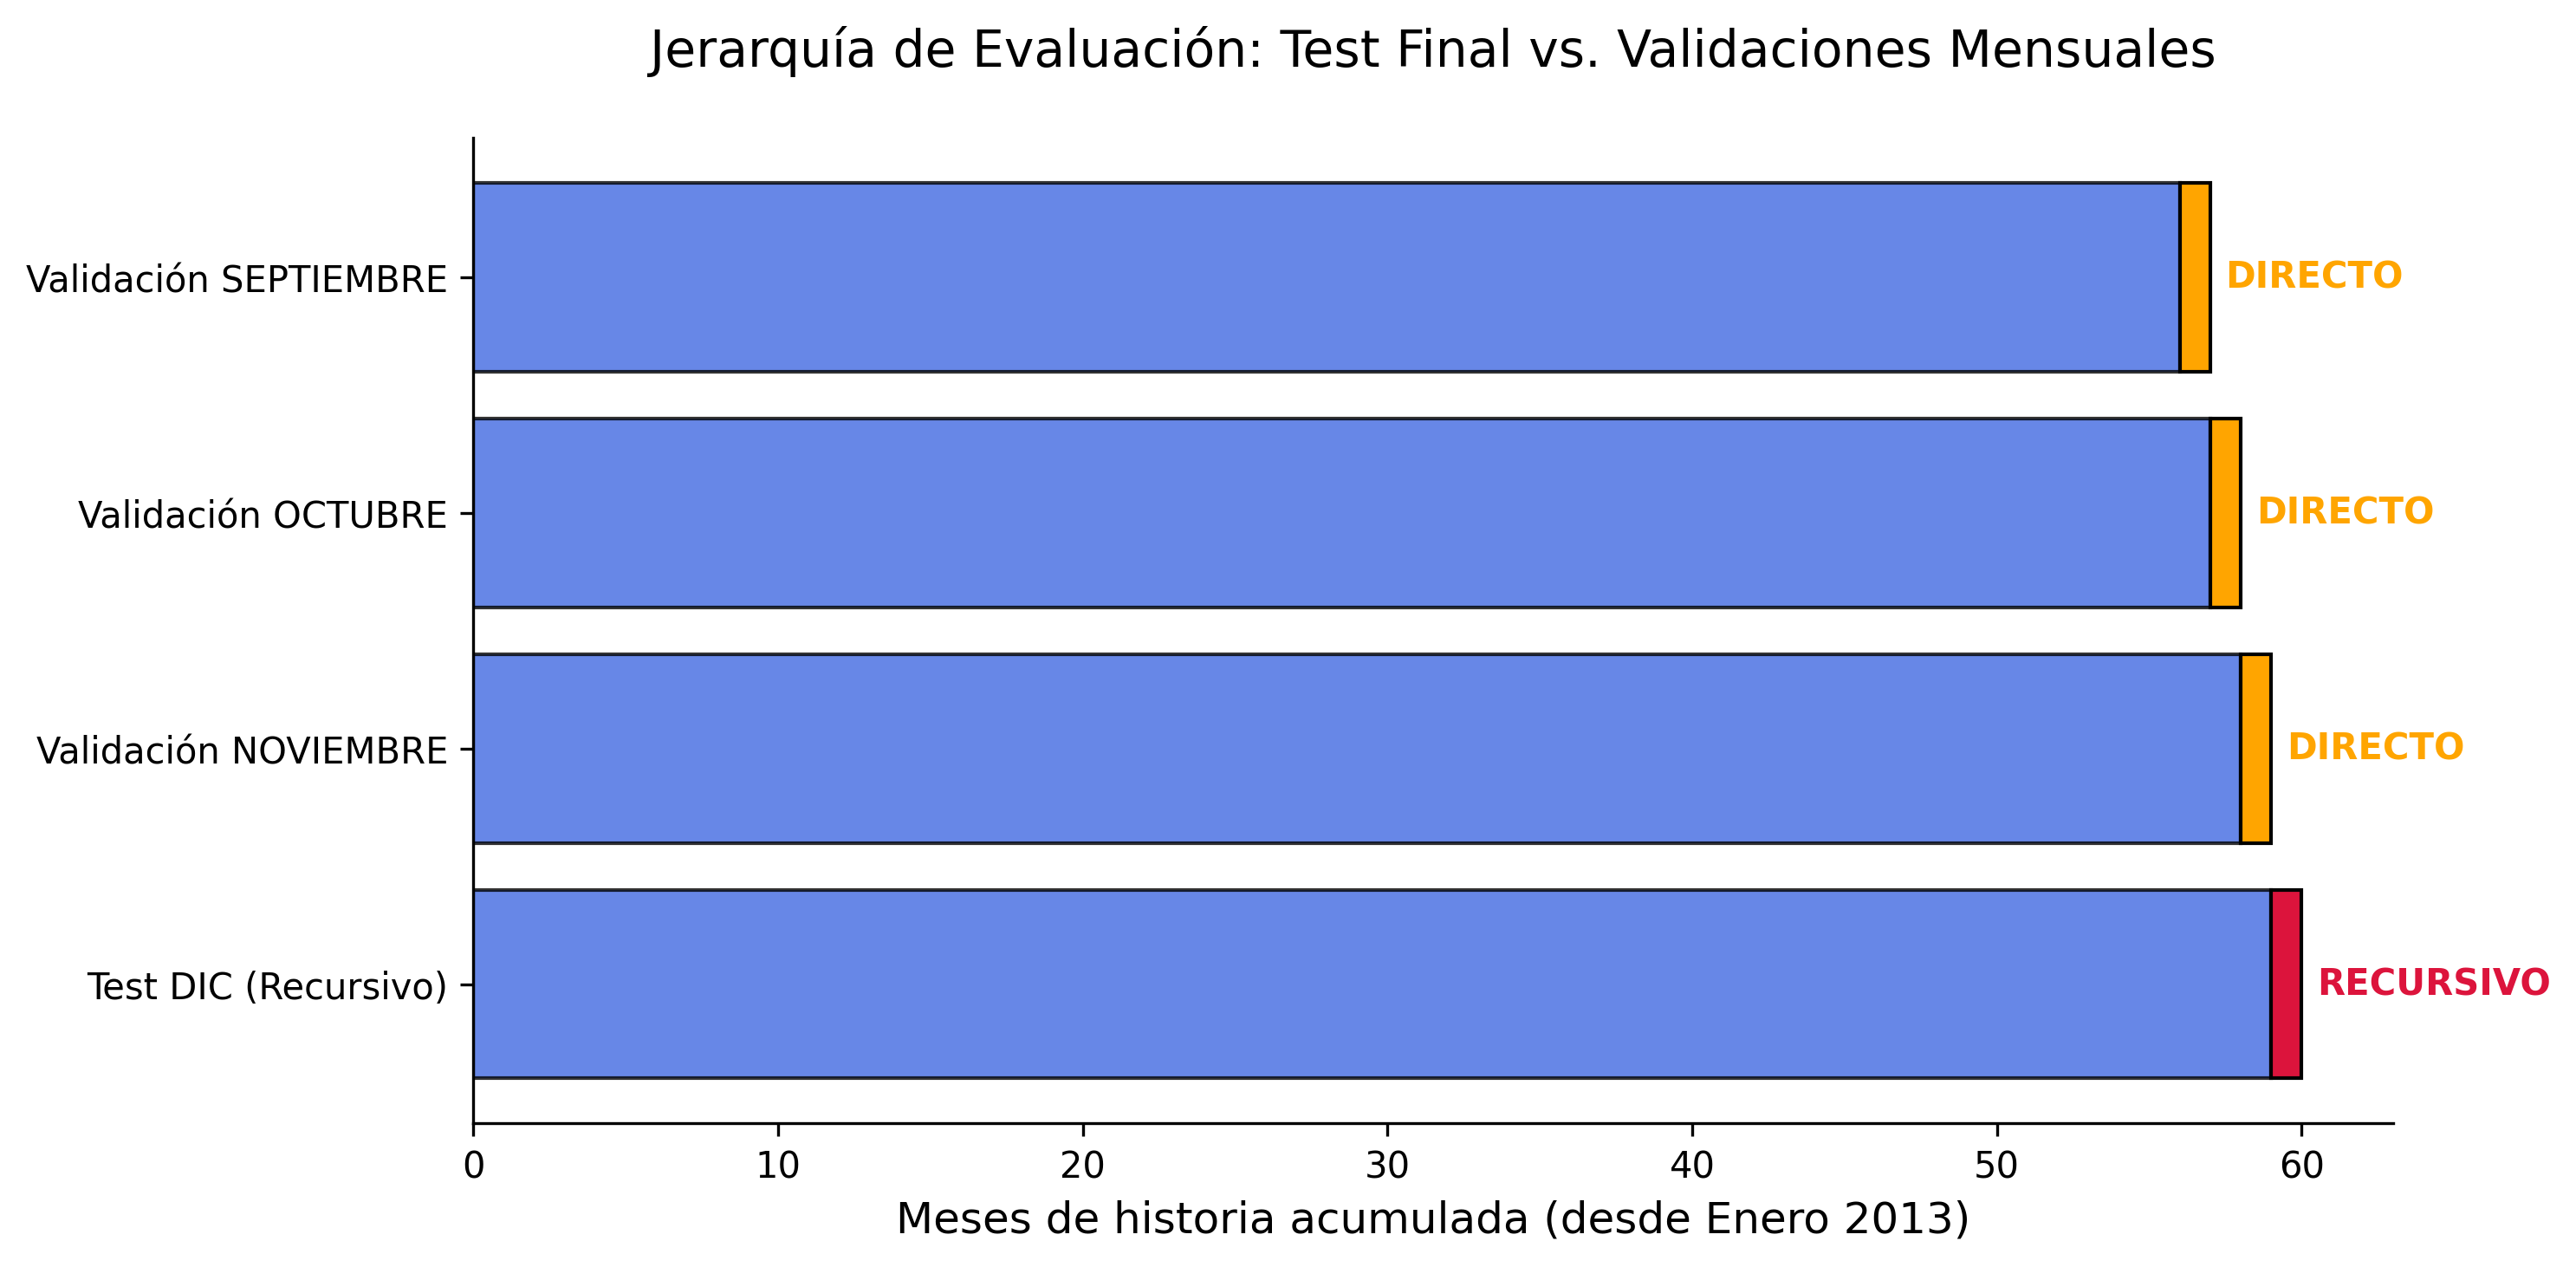

In [ ]:
from IPython.display import Image
Image(filename='/content/drive/MyDrive/You tube canal /PANDAS PARA SERIES DE TIEMPO/Random forest retail/grafico_validacion.png',
      width=700)

In [ ]:
features = ['store', 'item', "day",'dayofweek', 'month', 'year', 'dayofyear',
            'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_30',
            'rolling_mean_7', 'rolling_mean_30']

##### Metrica

### Métrica de Evaluación: SMAPE

El **El error porcentual absoluto medio simétrico(SMAPE)** es una medida de precisión basada en errores porcentuales. Es la métrica estándar para este tipo de desafíos porque ofrece un equilibrio entre el error absoluto y el valor real.

#### Fórmula Matemática
Se define como:

$$SMAPE = \frac{100\%}{n} \sum_{t=1}^{n} \frac{|F_t - A_t|}{(|A_t| + |F_t|)/2}$$

Donde:
* **$A_t$**: Valor Real (*Actual*).
* **$F_t$**: Valor de la Predicción (*Forecast*).
* **$n$**: Número total de observaciones.


In [ ]:
def smape(a, f):
    return 100/len(a) * np.sum(2 * np.abs(f - a) / (np.abs(a) + np.abs(f)))

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# Definimos los meses de validación
meses_val = [
    {'mes': 'Septiembre', 'train_until': '2017-08-31', 'test_start': '2017-09-01', 'test_end': '2017-09-30'},
    {'mes': 'Octubre',    'train_until': '2017-09-30', 'test_start': '2017-10-01', 'test_end': '2017-10-31'},
    {'mes': 'Noviembre',  'train_until': '2017-10-31', 'test_start': '2017-11-01', 'test_end': '2017-11-30'}
]

for m in meses_val:
    train = df_proc[df_proc['date'] <= m['train_until']]
    test = df_proc[(df_proc['date'] >= m['test_start']) & (df_proc['date'] <= m['test_end'])]

    rf = RandomForestRegressor(n_estimators=100, max_depth=12, n_jobs=-1, random_state=42)
    rf.fit(train[features], train["sales"])

    preds = rf.predict(test[features])
    print(f"Validación {m['mes']}: SMAPE = {smape(test["sales"], preds):.2f}%")

Validación Septiembre: SMAPE = 12.17%
Validación Octubre: SMAPE = 13.13%
Validación Noviembre: SMAPE = 12.35%


Modelo final:

In [ ]:
train_final = df_proc[df_proc['date'] <= '2017-11-30'].copy()
rf_final = RandomForestRegressor(n_estimators=100, max_depth=12, n_jobs=-1, random_state=42)
rf_final.fit(train_final[features], train_final["sales"])

RandomForestRegressor(max_depth=12, n_jobs=-1, random_state=42)

#### Prediccion Multi-step recursiva

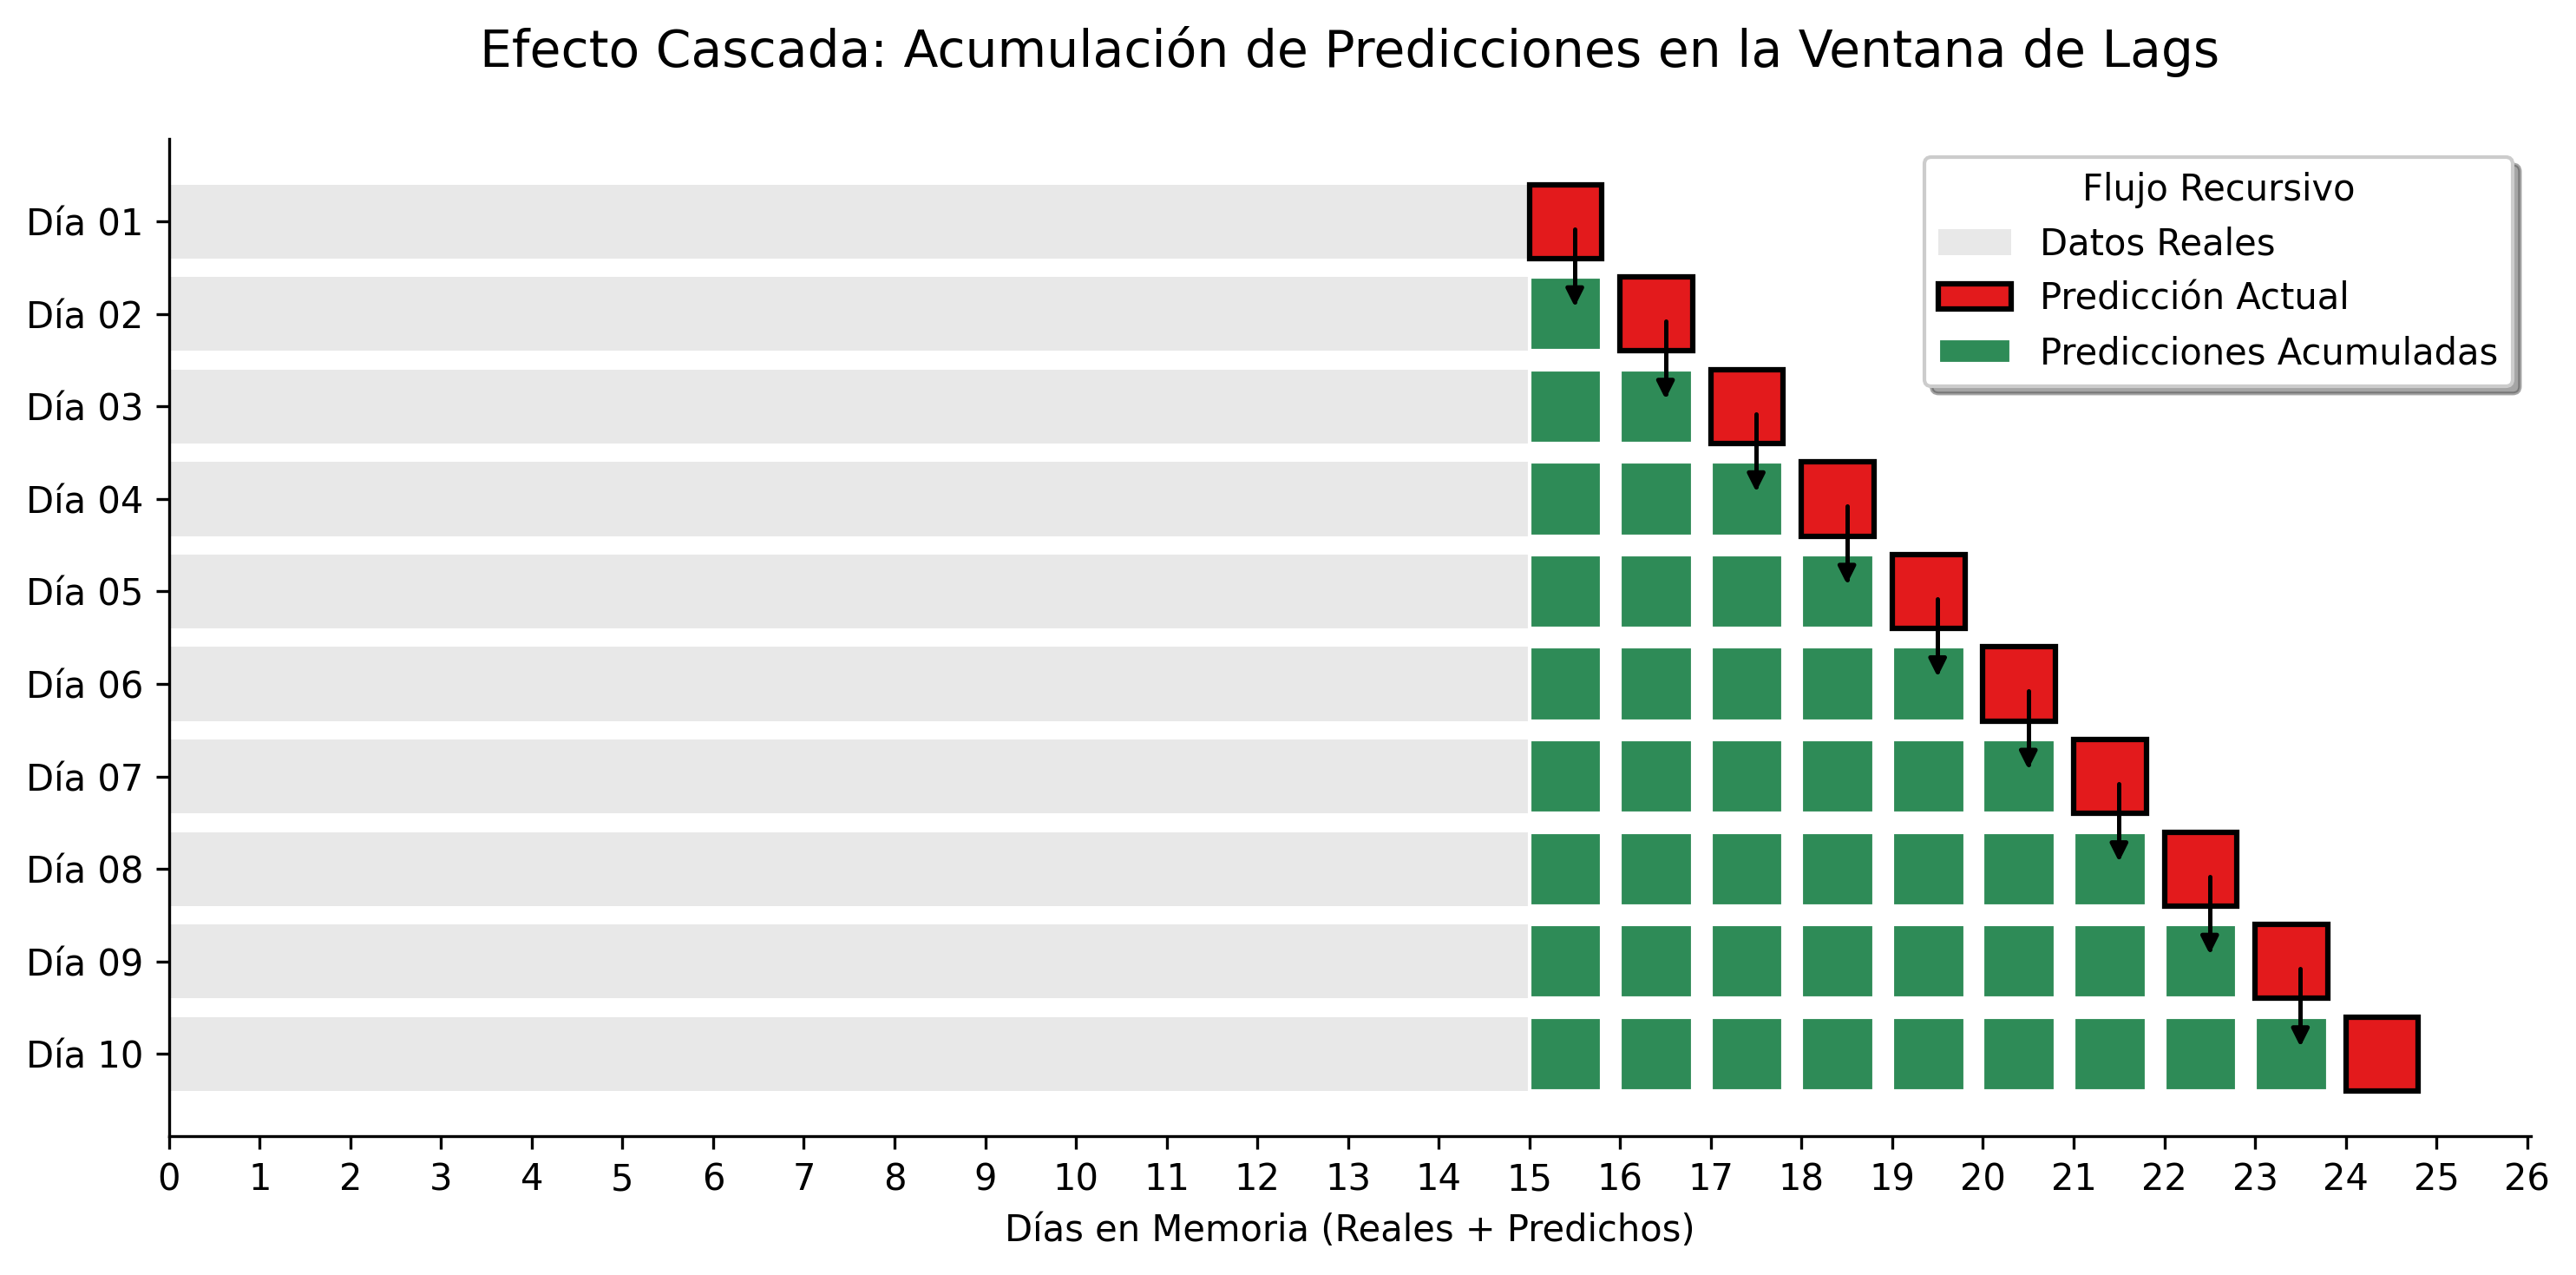

In [ ]:
Image(filename='/content/drive/MyDrive/You tube canal /PANDAS PARA SERIES DE TIEMPO/Random forest retail/grafico_recursivo (1).png',
      width=700)

In [ ]:
# 1. Preparar la base (últimos 60 días de noviembre hacia atrás)
# Filtramos para tener los datos necesarios para lags y rollings

historia_reciente = df_proc[(df_proc['date'] >= '2017-10-01') &
                            (df_proc['date'] <= '2017-11-30')].copy()
items_tiendas = df_store1[['store', 'item']].drop_duplicates()

predicciones_finales = []

for dia in range(1, 32):
    fecha_hoy = pd.Timestamp('2017-12-01') + pd.Timedelta(days=dia-1)

    # A. Crear filas vacías para el día de hoy
    hoy_df = items_tiendas.copy()
    hoy_df['date'] = fecha_hoy
    hoy_df['sales'] = 0

    # B. Unir con la historia para calcular los Lags
    # Usamos un temporal para no ensuciar 'historia_reciente' antes de tiempo
    temp_df = pd.concat([historia_reciente, hoy_df], ignore_index=True)
    temp_df = create_features(temp_df)

    # C. Extraer solo las filas de hoy con sus features calculadas
    batch_hoy = temp_df[temp_df['date'] == fecha_hoy].copy()

    # D. PREDECIR
    # El modelo usa los lags generados a partir de historia_reciente
    batch_hoy['sales'] = rf_final.predict(batch_hoy[features])

    # E. ACTUALIZAR HISTORIA (Solo con la predicción real)
    # Ahora sí, añadimos las predicciones a la historia para que el día siguiente las vea
    historia_reciente = pd.concat([historia_reciente, batch_hoy[['date',"store", 'item', 'sales']]], ignore_index=True)
    # Mantenemos la ventana deslizante para que no crezca infinito
    historia_reciente = historia_reciente[historia_reciente['date'] >= (fecha_hoy - pd.Timedelta(days=60))]
    print(fecha_hoy)
    # Guardamos el resultado del día
    predicciones_finales.append(batch_hoy)

# Unir todos los días de diciembre en un solo DataFrame
df_diciembre = pd.concat(predicciones_finales, ignore_index=True)

2017-12-01 00:00:00
2017-12-02 00:00:00
2017-12-03 00:00:00
2017-12-04 00:00:00
2017-12-05 00:00:00
2017-12-06 00:00:00
2017-12-07 00:00:00
2017-12-08 00:00:00
2017-12-09 00:00:00
2017-12-10 00:00:00
2017-12-11 00:00:00
2017-12-12 00:00:00
2017-12-13 00:00:00
2017-12-14 00:00:00
2017-12-15 00:00:00
2017-12-16 00:00:00
2017-12-17 00:00:00
2017-12-18 00:00:00
2017-12-19 00:00:00
2017-12-20 00:00:00
2017-12-21 00:00:00
2017-12-22 00:00:00
2017-12-23 00:00:00
2017-12-24 00:00:00
2017-12-25 00:00:00
2017-12-26 00:00:00
2017-12-27 00:00:00
2017-12-28 00:00:00
2017-12-29 00:00:00
2017-12-30 00:00:00
2017-12-31 00:00:00


In [ ]:
df_real_diciembre=df_store1[df_store1['date']>="2017-12-01"].copy()

In [ ]:
df_diciembre2=df_diciembre.sort_values(by=["store","item","date"])

In [ ]:
smape(df_real_diciembre["sales"].values,df_diciembre2["sales"].values)

np.float64(20.63339990222933)

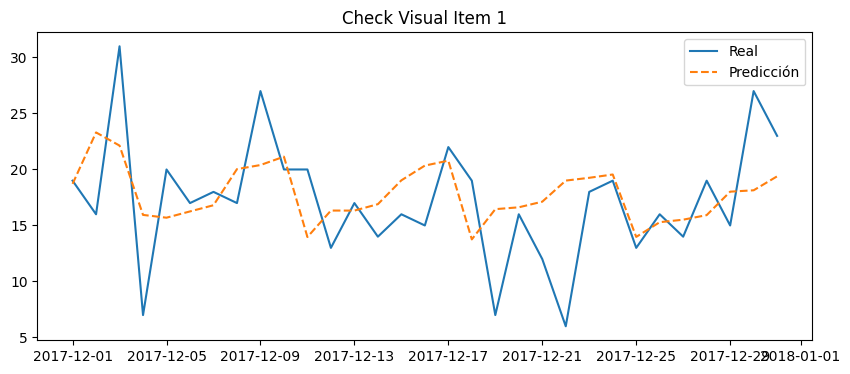

In [ ]:
import matplotlib.pyplot as plt

# 1. Mira los primeros 5 días vs los últimos 5
df_comparar = df_real_diciembre[['date', 'sales',"item"]].reset_index(drop=True).copy()
df_comparar['pred'] = df_diciembre2['sales'].values

# Grafica un item específico
item_id = 1
temp = df_comparar[df_comparar['item'] == item_id]

plt.figure(figsize=(10,4))
plt.plot(temp['date'], temp['sales'], label='Real')
plt.plot(temp['date'], temp['pred'], label='Predicción', ls='--')
plt.title(f"Check Visual Item {item_id}")
plt.legend()
plt.show()